In [8]:
%load_ext autoreload
%autoreload 2
from PyPDF2 import PdfReader
import os
import amrlib
import penman
import torch
from amrlib import load_stog_model
import networkx as nx
import sys, os
from pyvis.network import Network
import matplotlib.pyplot as plt
import amrlib
import spacy
from tools.sentence.sentence import Sentence
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from kg.formatting.formatting_manager import FormattingManager
import sys, importlib,os
sys.modules.pop('PatentTextFormatter', None)
importlib.invalidate_caches()
import numpy as np
from kg.cleaning.normalising.word_normaliser import WordNormaliser
from fastcoref import FCoref
import kg.cleaning.referencing.spacy_pipeline_patent
from tools.sentence.entity import Entity
import torch, os, platform
from kg.generating_kg.generating.NodeGenerator import NodeGenerator
import spacy
from kg.cleaning.referencing.spacy_pipeline_patent import SpacyPipeline
import os, pyvis, jinja2, sys
import epo_ops
import epo_ops
import os
import spacy
import xml.etree.ElementTree as ET
import json
import sys
from kg.generating_kg.analysing.TextEncoder import TextEncoder

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
import torch, os, platform

print("torch:", torch.__version__)
print("cuda available:", torch.cuda.is_available())
print("torch.version.cuda:", torch.version.cuda)   # None == CPU-only build
print("gpu count:", torch.cuda.device_count())

if torch.cuda.is_available():
    print("name[0]:", torch.cuda.get_device_name(0))
    print("capability[0]:", torch.cuda.get_device_capability(0))
else:
    print("No CUDA device visible to PyTorch.")

torch: 2.7.1+cu128
cuda available: True
torch.version.cuda: 12.8
gpu count: 1
name[0]: NVIDIA GeForce RTX 5070 Ti
capability[0]: (12, 0)


In [4]:
formatterManager = FormattingManager()
segment_split = formatterManager.split_segments("A computing apparatus configured to dynamically allocate processing resources among a plurality of concurrent machine-learning inference tasks based on predictive workload analysis, wherein said allocation is continuously optimized through feedback derived from real-time performance metrics and latency constraints.")
print("split" + str(segment_split))

11/23/2025 21:38:42 - INFO - 	 Use pytorch device_name: cuda:0
11/23/2025 21:38:42 - INFO - 	 Load pretrained SentenceTransformer: sentence-transformers/all-MiniLM-L6-v2


split['A computing apparatus configured to dynamically allocate processing resources among a plurality of concurrent machine-learning inference tasks based on predictive workload analysis, wherein said allocation is continuously optimized through feedback derived from real-time performance metrics and latency constraints.']


In [4]:
nlp = spacy.load("en_core_web_sm")
formatterManager = FormattingManager()
sentence_split = [[]]
for i in range(0,len(segment_split)):
    doc = nlp(segment_split[i])
    sentences = [sent.text.strip() for sent in doc.sents]
    sentence_str = ""
    for c in sentences:
        sentence_split[i].extend(formatterManager.split(c))

print(sentence_split[0])



11/23/2025 21:00:36 - INFO - 	 Use pytorch device_name: cuda:0
11/23/2025 21:00:36 - INFO - 	 Load pretrained SentenceTransformer: sentence-transformers/all-MiniLM-L6-v2


State


11/23/2025 21:00:41 - INFO - 	 HTTP Request: POST https://api.anthropic.com/v1/messages "HTTP/1.1 200 OK"


Raw: ```json
[
  "A computing apparatus is configured to dynamically allocate processing resources among a plurality of concurrent machine-learning inference tasks.",
  "The allocation is based on predictive workload analysis.",
  "Said allocation is continuously optimized through feedback derived from real-time performance metrics and latency constraints."
]
``` State: {'text': 'A computing apparatus is configured to dynamically allocate processing resources among a plurality of concurrent machine-learning inference tasks. Said allocation is continuously optimized through feedback derived from real-time performance metrics and latency constraints.', 'sentences': ['A computing apparatus is configured to dynamically allocate processing resources among a plurality of concurrent machine-learning inference tasks.', 'The allocation is based on predictive workload analysis.', 'Said allocation is continuously optimized through feedback derived from real-time performance metrics and latency co

11/23/2025 21:00:43 - INFO - 	 HTTP Request: POST https://api.anthropic.com/v1/messages "HTTP/1.1 200 OK"


Raw: ```json
[
  "A computing apparatus is configured to dynamically allocate processing resources among a plurality of concurrent machine-learning inference tasks.",
  "Said allocation is continuously optimized through feedback derived from real-time performance metrics and latency constraints."
]
``` State: {'text': 'A computing apparatus is configured to dynamically allocate processing resources among a plurality of concurrent machine-learning inference tasks. Said allocation is continuously optimized through feedback derived from real-time performance metrics and latency constraints.', 'sentences': ['A computing apparatus is configured to dynamically allocate processing resources among a plurality of concurrent machine-learning inference tasks.', 'The allocation is based on predictive workload analysis.', 'Said allocation is continuously optimized through feedback derived from real-time performance metrics and latency constraints.'], 'improvement': None, 'done': True} iteration: 2


In [5]:
rule_based = [[]]
for i, c in enumerate(sentence_split):
    for d in c:
        print("Snip " + d.text)
        rule = formatterManager.rule_standardiser(
            d.text
        )
        rule_based[i].append(rule[i].text)  # replace the old element
print(sentence_split)
print(rule_based[0])


        



Snip A computing apparatus is configured to dynamically allocate processing resources among a plurality of concurrent machine-learning inference tasks.
Run sentence simplifier


11/23/2025 21:00:45 - INFO - 	 HTTP Request: POST https://api.anthropic.com/v1/messages "HTTP/1.1 200 OK"
11/23/2025 21:00:49 - INFO - 	 HTTP Request: POST https://api.anthropic.com/v1/messages "HTTP/1.1 200 OK"
11/23/2025 21:00:52 - INFO - 	 HTTP Request: POST https://api.anthropic.com/v1/messages "HTTP/1.1 200 OK"


Snip The allocation is based on predictive workload analysis.
Run sentence simplifier


11/23/2025 21:00:53 - INFO - 	 HTTP Request: POST https://api.anthropic.com/v1/messages "HTTP/1.1 200 OK"


Snip Said allocation is continuously optimized through feedback derived from real-time performance metrics and latency constraints.
Run sentence simplifier


11/23/2025 21:00:54 - INFO - 	 HTTP Request: POST https://api.anthropic.com/v1/messages "HTTP/1.1 200 OK"
11/23/2025 21:00:56 - INFO - 	 HTTP Request: POST https://api.anthropic.com/v1/messages "HTTP/1.1 200 OK"
11/23/2025 21:00:57 - INFO - 	 HTTP Request: POST https://api.anthropic.com/v1/messages "HTTP/1.1 200 OK"


[[Sentence(text='A computing apparatus is configured to dynamically allocate processing resources among a plurality of concurrent machine-learning inference tasks.', index=0, source='', span=None, id='d52cec49-95fe-49a3-bea5-b22b04ae466f', kg_node_id=None, embedding=None, tokens=[], entities={}, tags=[], importance=0.5, info_quality=0.5, novelty=None, lang='en'), Sentence(text='The allocation is based on predictive workload analysis.', index=1, source='', span=None, id='0bf1d41e-0b08-4919-abeb-c1935746ee04', kg_node_id=None, embedding=None, tokens=[], entities={}, tags=[], importance=0.5, info_quality=0.5, novelty=None, lang='en'), Sentence(text='Said allocation is continuously optimized through feedback derived from real-time performance metrics and latency constraints.', index=2, source='', span=None, id='05217614-a925-4223-871d-9c026a315bd2', kg_node_id=None, embedding=None, tokens=[], entities={}, tags=[], importance=0.5, info_quality=0.5, novelty=None, lang='en')]]
['A computing a

In [6]:
print(rule_based[0][1])
for c,i in enumerate(rule_based):
    for i in rule_based[c]:
        simplify = formatterManager.simplify(i)
        print(simplify)



[GENERIC] Predictive workload analysis determines the allocation.
['a', 'computing', 'apparatus', 'dynamically', 'allocate', 'processing', 'resource', 'among', 'a', 'plurality', 'of', 'concurrent', 'machine', '-', 'learn', 'inference', 'task', '.']
['[', 'generic', ']', 'predictive', 'workload', 'analysis', 'determine', 'the', 'allocation', '.']
['[', 'assumption', ']', 'the', 'system', 'continuously', 'optimize', 'say', 'allocation', 'through', 'feedback', 'derive', 'from', 'real', '-', 'time', 'performance', 'metric', 'and', 'latency', 'constraint', '.']


In [7]:
# spacy_pipeline_patent.py (add this at the bottom, optional helper)

pipeline = SpacyPipeline()

sentence1 = Sentence(text="Caleb is soon 22.")
sentence2 = Sentence(text= "Caleb birthday is in half a year.")
sentence3 = Sentence(text="His brother is called Nathan.")
sentence4 = Sentence(text="Nathan is going to be 24 soon.")

sentences = [sentence1, sentence2, sentence3, sentence4]
joined_text = "".join(s.text for s in sentences)
doc = pipeline.nlp(joined_text)
sentence_starts = pipeline.indexes_sentences(sentences)
clusters = pipeline.fill_coref_entities(doc,sentence_starts, sentences)
cluster_spans = pipeline.get_cluster_spans(clusters)
pipeline.add_entities_from_ner(doc,cluster_spans=cluster_spans,sentence_starts=sentence_starts,sentences=sentences)
pipeline.normalise_other_refs_to_first(sentences)
pipeline.generate_normalised_text(sentences)

11/23/2025 21:03:20 - INFO - 	 missing_keys: []
11/23/2025 21:03:20 - INFO - 	 unexpected_keys: []
11/23/2025 21:03:20 - INFO - 	 mismatched_keys: []
11/23/2025 21:03:20 - INFO - 	 error_msgs: []
11/23/2025 21:03:20 - INFO - 	 Model Parameters: 90.5M, Transformer: 82.1M, Coref head: 8.4M
11/23/2025 21:03:20 - INFO - 	 Tokenize 1 inputs...
Map: 100%|██████████| 1/1 [00:00<00:00, 66.45 examples/s]
11/23/2025 21:03:21 - INFO - 	 ***** Running Inference on 1 texts *****
Inference: 100%|██████████| 1/1 [00:00<00:00, 13.31it/s]


Sentence 0: Caleb is soon 22.
  [0:5] Caleb Reference  ref=Caleb
Caleb is soon 22.
  [14:22] 22.Caleb PERSON  ref=22.Caleb
Caleb is soon 22.

Sentence 1: Caleb birthday is in half a year.
  [21:32] half a year DATE  ref=half a year
Caleb birthday is in half a year.

Sentence 2: Caleb brother is called Nathan.
  [0:3] His Reference  ref=Caleb
Caleb brother is called Nathan.
  [22:28] Nathan PERSON  ref=Nathan
Caleb brother is called Nathan.

Sentence 3: Nathan is going to be 24 soon.
  [0:6] Nathan PERSON  ref=Nathan
Nathan is going to be 24 soon.
  [22:24] 24 DATE  ref=24
Nathan is going to be 24 soon.


In [9]:

from sentence_transformers import SentenceTransformer
model = SentenceTransformer("all-MiniLM-L6-v2")
DIM = model.get_sentence_embedding_dimension()

def embed_word(w: str) -> np.ndarray:
    v = model.encode(w, normalize_embeddings=True)
    return np.asarray(v, dtype="float32")

norm = WordNormaliser(embed_fn=embed_word, dim=DIM, threshold=0.72)


11/30/2025 19:46:41 - INFO - 	 Use pytorch device_name: cuda:0
11/30/2025 19:46:41 - INFO - 	 Load pretrained SentenceTransformer: all-MiniLM-L6-v2


KeyboardInterrupt: 

In [9]:
amrlib.__file__
stog = amrlib.load_stog_model()


In [48]:

sentences_simpel = [
    '[_caleb123_person] is 21',
    '[_caleb123_person] lives in Munich',
    '[_caleb123_person] was born in Berlin',
    '[_nathan123_person] lives in Marburg',
    '[_nathan123_person] and [_caleb123_person] are brothers',
    '[_emma123_person] is 19',
    '[_emma123_person] studies biology',
    '[_emma123_person] lives in Berlin',
    '[_caleb123_person] and [_emma123_person] are friends',
    '[_nathan123_person] studies engineering',
    '[_caleb123_person] works at a bookstore',
    '[_emma123_person] likes music',
    '[_nathan123_person] likes football',
    '[_caleb123_person] and [_nathan123_person] play football together',
    '[_emma123_person] has a cat',
    '[_caleb123_person] likes [_emma123_person] cat',
    '[_nathan123_person] has a dog',
    '[_caleb123_person] and [_nathan123_person] walk the dog on weekends',
    '[_emma123_person] and [_caleb123_person] go to concerts',
    '[_caleb123_person] favorite band is Coldplay',
    '[_emma123_person] studies at Humboldt University',
    '[_nathan123_person] studies at Marburg University',
    'Caleb visits [_nathan123_person] in Marburg',
    '[_emma123_person] and [_nathan123_person] met last summer',
    '[_emma123_person] and [_caleb123_person] met at school',
    '[_caleb123_person] mother is a teacher',
    '[_nathan123_person] father is a doctor',
    '[_emma123_person] brother is 15',
    '[_caleb123_person] and [_nathan123_person] grew up in Berlin',
    '[_caleb123_person] moved to Munich last year',
    '[_nathan123_person] stayed in Marburg for his studies',
    'Emm[_emma123_person]a and [_nathan123_person] text often',
    '[_caleb123_person] calls [_emma123_person] on weekends',
    '[_nathan123_person] and [_caleb123_person] visit their parents in Berlin',
    '[_emma123_person] likes to travel',
    '[_caleb123_person] wants to visit Paris',
    '[_nathan123_person] visited Paris last year',
    '[_emma123_person] and [_caleb123_person] plan to visit Paris together',
    '[_caleb123_person] likes coffee',
    '[_emma123_person] prefers tea',
    '[_nathan123_person] drinks tea in the morning',
    '[_caleb123_person] and [_nathan123_person] share an apartment in summer',
    '[_emma123_person] comes over for dinner sometimes',
    '[_caleb123_person] cooks pasta often',
    '[_nathan123_person] helps with dishes',
    '[_emma123_person] brings dessert',
    '[_nathan123_person] and [_emma123_person] take photos together',
    '[_nathan123_person] posts photos on social media',
    '[_emma123_person] studies every morning',
    '[_caleb123_person] goes jogging in the park',
    '[_emma123_person] rides his bike to university'
]
sentences_patent_style_prev = [
    'It is determined that the individual identified as [_caleb123_person] possesses an age of 21 years.',
    'The residence of [_caleb123_person] is established to be within the geographic region of [_munich_city].',
    'The origin of [_caleb123_person] is recorded as the municipality of [_berlin_city].',
    'The individual designated as [_nathan123_person] is located within the city of [_marburg_city].',
    'A fraternal relationship exists between [_nathan123_person] and [_caleb123_person].',
    'The individual referenced as [_emma123_person] possesses an age of 19 years.',
    '[_emma123_person] is engaged in an academic program in the field of [_biology_field].',
    '[_emma123_person] maintains a primary residence in the region of [_berlin_city].',
    'A social-association relationship is established between [_caleb123_person] and [_emma123_person].',
    '[_nathan123_person] is enrolled in a technical academic discipline identified as [_engineering_field].',
    '[_caleb123_person] performs occupational duties at the commercial establishment designated as [_bookstore_org].',
    'The individual [_emma123_person] exhibits a preference for the domain of [_music_field].',
    '[_nathan123_person] exhibits a preference for the activity identified as [_football_activity].',
    '[_caleb123_person] and [_nathan123_person] jointly participate in the activity of [_football_activity].',
    'The individual [_emma123_person] owns a domesticated animal classified as [_cat123_animal].',
    '[_caleb123_person] demonstrates a favorable disposition toward the [_cat123_animal] owned by [_emma123_person].',
    '[_nathan123_person] possesses a domesticated animal classified as [_dog123_animal].',
    '[_caleb123_person] and [_nathan123_person] engage in ambulatory activity with the [_dog123_animal] during weekends.',
    '[_emma123_person] and [_caleb123_person] participate together in attending musical-performance events.',
    'The preferred musical group of [_caleb123_person] is the entity designated as [_coldplay_band].',
    '[_emma123_person] conducts academic studies at the institution identified as [_humboldt_university].',
    '[_nathan123_person] conducts academic studies at the institution identified as [_marburg_university].',
    'The individual [_caleb123_person] performs visitation to [_nathan123_person] within the region of [_marburg_city].',
    '[_emma123_person] and [_nathan123_person] established initial contact during the temporal interval defined as last summer.',
    '[_emma123_person] and [_caleb123_person] initiated acquaintance during their attendance at [_school_generic].',
    'The maternal guardian of [_caleb123_person] is employed in the profession designated as [_teacher_profession].',
    'The paternal guardian of [_nathan123_person] is employed in the medical profession identified as [_doctor_profession].',
    'The brother of [_emma123_person] possesses an age of 15 years.',
    '[_caleb123_person] and [_nathan123_person] experienced upbringing within the region of [_berlin_city].',
    '[_caleb123_person] relocated to [_munich_city] during the previous calendar year.',
    '[_nathan123_person] remained within the region of [_marburg_city] for purposes associated with his academic studies.',
    '[_emma123_person] and [_nathan123_person] engage in text-based digital communication with high frequency.',
    '[_caleb123_person] establishes telephonic communication with [_emma123_person] during weekends.',
    '[_nathan123_person] and [_caleb123_person] conduct periodic parental visits within the region of [_berlin_city].',
    '[_emma123_person] exhibits a preference for travel-related activities.',
    '[_caleb123_person] expresses intent to conduct travel to [_paris_city].',
    '[_nathan123_person] conducted travel to [_paris_city] during the previous year.',
    '[_emma123_person] and [_caleb123_person] formulate a joint plan to conduct travel to [_paris_city].',
    '[_caleb123_person] demonstrates a preference for the consumable commodity identified as [_coffee_beverage].',
    '[_emma123_person] demonstrates a preference for the consumable commodity identified as [_tea_beverage].',
    '[_nathan123_person] consumes the beverage [_tea_beverage] during morning intervals.',
    '[_caleb123_person] and [_nathan123_person] occupy a shared residential unit during the summer season.',
    '[_emma123_person] performs occasional visitations for the purpose of participating in evening meals.',
    '[_caleb123_person] frequently prepares a food product categorized as [_pasta_food].',
    '[_nathan123_person] provides assistance with post-meal cleaning operations.',
    '[_emma123_person] supplies dessert items during shared meals.',
    '[_nathan123_person] and [_emma123_person] engage in photographic-capture activities together.',
    '[_nathan123_person] publishes said photographic content on digital social-media platforms.',
    '[_emma123_person] conducts academic study during morning intervals on a routine basis.',
    '[_caleb123_person] engages in jogging activity within the designated park region [_park_generic].',
    '[_emma123_person] utilizes a bicycle for transportation to the institution identified as [_humboldt_university].'
]
sentences_patent = [
    'A system comprising a primary device identified as [_deviceA_device], wherein [_deviceA_device] is configured to receive sensory data from a sensor unit designated as [_sensor12_component].',
    'The sensor unit [_sensor12_component] is operatively coupled to a processing module identified as [_moduleX_processor] for performing signal interpretation.',
    'A data-storage element referred to as [_storageUnit_memory] is configured to retain operational parameters associated with [_deviceA_device].',
    'Upon detection of motion within a monitored region designated as [_zoneAlpha_region], the processor [_moduleX_processor] initiates a transmission to a remote server identified as [_server99_network].',
    'The remote server [_server99_network] maintains communication with a user-operated terminal defined as [_terminalUser_interface].',
    'A user entity identified as [_user01_person] interacts with [_terminalUser_interface] to modify control settings of [_deviceA_device].',
    'A transportation module identified as [_vehicle42_machine] is configured to navigate toward a destination region labeled as [_berlin_city].',
    'The propulsion subsystem of [_vehicle42_machine] utilizes a fuel source indicated as [_batteryPack_energySource].',
    'A companion animal designated as [_cat123_animal] is tracked via a wearable tag identified as [_tagX_trackingDevice].',
    'The wearable tag [_tagX_trackingDevice] transmits location data to a monitoring platform defined as [_platformGeo_system].',
    'A manufacturing assembly comprising a robotic arm identified as [_armUnit_robot] performs automated manipulation of components within a workspace labeled as [_workspace1_area].',
    'The robotic arm [_armUnit_robot] receives positional instructions generated by a controller entity identified as [_controller7_unit].',
    'A storage facility defined as [_warehouse55_structure] houses inventory items categorized under a product class marked as [_productClassA_material].',
    'A drone unit labeled as [_drone23_vehicle] is configured to transport said product class [_productClassA_material] to a target delivery zone identified as [_targetZone_deliveryRegion].',
    'Environmental data retrieved from a climate sensor designated as [_climateSensor_tempUnit] is transmitted to a central analytics engine referred to as [_analyticsCore_processor].',
    'The analytics engine [_analyticsCore_processor] generates operational recommendations for machinery located within the region identified as [_factoryWest_zone].',
    'An agricultural field defined as [_fieldOmega_land] contains growth units corresponding to a plant species labeled as [_plantTypeK_species].',
    'A hydration module designated as [_irrigationSystem_unit] supplies water to [_plantTypeK_species] based on thresholds monitored by [_climateSensor_tempUnit].',
    'A navigation system comprising a mapping element identified as [_mapEngine_module] computes a route between a first location marked as [_munich_city] and a second location marked as [_paris_city].',
    'A communication interface labeled as [_commUnit_link] enables data exchange between [_vehicle42_machine] and the mapping element [_mapEngine_module].',
    'A localization subsystem identified as [_localizerGamma_unit] triangulates the position of [_deviceA_device] relative to landmarks stored in [_mapEngine_module].',
    'A power-regulation unit marked as [_powerReg_unit] supplies conditioned electrical energy to [_armUnit_robot] during peak mechanical load cycles.',
    'A safety enclosure identified as [_safetyShell_structure] surrounds the workspace [_workspace1_area] to prevent human contact with active robotic elements.',
    'A computing cluster labeled as [_clusterDelta_server] executes machine-learning models used to optimize the route selection process of [_drone23_vehicle].',
    'A docking station defined as [_dockStation_port] is configured to recharge the battery module [_batteryPack_energySource] of [_vehicle42_machine].',
    'A thermal-management component identified as [_coolingModule_system] dissipates heat generated by [_moduleX_processor] under sustained computational loads.',
    'A filtration subsystem labeled as [_filterZ_element] removes particulate contaminants from air entering the housing of [_analyticsCore_processor].',
    'A secure communication channel marked as [_secureLink_protocol] encrypts transmissions between [_terminalUser_interface] and [_server99_network].',
    'A camera module designated as [_cameraA_optic] captures image data from the environment surrounding [_deviceA_device].',
    'The image data from [_cameraA_optic] is analyzed by an image-processing unit identified as [_visionProcessor_unit].',
    'A charging cradle labeled as [_cradleUnit_dock] maintains electrical connectivity with the wearable device [_tagX_trackingDevice].',
    'A structural frame defined as [_frameK_structure] supports the positioning of [_sensor12_component] within [_zoneAlpha_region].',
    'A movable platform marked as [_platformR_mobileBase] transports components across the assembly zone [_workspace1_area].',
    'The mobile platform [_platformR_mobileBase] receives navigational data from the controller entity [_controller7_unit].',
    'An audio transducer identified as [_audioUnit_speaker] provides alert notifications generated by [_analyticsCore_processor].',
    'A lighting module labeled as [_lightModule_LED] illuminates [_workspace1_area] when the robotic arm [_armUnit_robot] is active.',
    'A material container designated as [_containerM_unit] stores batches of [_productClassA_material] prior to drone loading operations.',
    'A payload compartment marked as [_payloadCompartment_section] of [_drone23_vehicle] is configured to secure transported materials during flight.',
    'A vibration sensor identified as [_vibSensor_component] detects oscillation levels on [_vehicle42_machine] during traversal.',
    'A coolant reservoir labeled as [_coolantTank_unit] supplies coolant fluid to the thermal-management component [_coolingModule_system].',
    'A gateway device defined as [_gatewayNode_device] routes data packets between [_platformGeo_system] and [_server99_network].',
    'An access control module identified as [_authUnit_security] validates user credentials submitted via [_terminalUser_interface].',
    'An energy-harvesting device labeled as [_solarPanel_unit] provides supplemental charging power to [_batteryPack_energySource].',
    'A weather-monitoring assembly defined as [_weatherStation_system] collects atmospheric readings within [_fieldOmega_land].',
    'The atmospheric readings from [_weatherStation_system] are forwarded to the irrigation controller [_irrigationSystem_unit].',
    'A biomechanical sensor identified as [_bioSensorX_unit] measures growth metrics of [_plantTypeK_species].',
    'A soil-analysis module labeled as [_soilModule_analyzer] determines moisture distribution across [_fieldOmega_land].',
    'A multi-axis controller defined as [_axisController_module] regulates movement of the robotic arm [_armUnit_robot] along three orthogonal directions.',
    'A proximity detector marked as [_proxSensor_component] halts the motion of [_vehicle42_machine] upon detecting obstacles.',
    'A wireless antenna unit identified as [_antennaQ_component] facilitates long-range communication between [_drone23_vehicle] and [_server99_network].',
    'A distributed ledger node labeled as [_ledgerNode_system] records operational logs generated by [_analyticsCore_processor].',
    'A graphical display referred to as [_displayHMI_interface] presents real-time system diagnostics to [_user01_person].',
    'A mechanical fastening element identified as [_fastenerB_component] secures [_sensor12_component] to the structural frame [_frameK_structure].',

    # --- EXTENDED SENTENCES START HERE ---
    'A kinetic actuator identified as [_actuatorJ_mechanism] adjusts the orientation of [_cameraA_optic] based on control signals from [_controller7_unit].',
    'A rechargeable cell cluster labeled as [_cellCluster_powerUnit] is integrated within the power subsystem of [_deviceA_device].',
    'A microfluidic valve identified as [_valveMicro_component] regulates coolant flow within [_coolingModule_system].',
    'An autonomous guidance module marked as [_guideModule_navUnit] computes detour paths for [_vehicle42_machine].',
    'A multiband transceiver labeled as [_transceiverMB_radio] establishes wireless connectivity with [_gatewayNode_device].',
    'A structural housing defined as [_housingZ_shell] encloses the processing circuitry of [_visionProcessor_unit].',
    'A biometric scanner identified as [_bioScanR_sensor] authenticates access requests by [_user01_person].',
    'A force-feedback interface labeled as [_hapticControl_unit] provides tactile responses to inputs on [_terminalUser_interface].',
    'A motion-capture beacon designated as [_mocapBeacon_marker] transmits real-time position updates to [_localizerGamma_unit].',
    'A firmware module identified as [_fwModule_beta] governs initialization routines of [_analyticsCore_processor].',
    'A scheduling engine marked as [_scheduleEngine_unit] coordinates operational cycles across [_factoryWest_zone].',
    'A turbulence detector labeled as [_turbulenceSensor_airUnit] monitors aerodynamic stability of [_drone23_vehicle].',
    'A packaging robot identified as [_packerUnit_robot] organizes [_productClassA_material] for shipment in [_warehouse55_structure].',
    'A multi-tier container system defined as [_containerStack_system] stores categorized inventory within [_warehouse55_structure].',
    'A navigation beacon labeled as [_navBeacon_signalSource] provides positional corrections to [_mapEngine_module].',
    'A fusion processor identified as [_fusionProc_unit] combines sensory streams from [_sensor12_component] and [_cameraA_optic].',
    'A pressure-sensitive panel marked as [_pressurePanel_interface] detects manual input from [_user01_person].',
    'A composite insulation layer labeled as [_insulationLayer_material] protects [_batteryPack_energySource] from thermal excursions.',
    'A hazard-detection unit identified as [_hazardUnit_detector] triggers alerts through [_audioUnit_speaker].',
    'A calibration module designated as [_calibModule_unit] adjusts performance parameters of [_climateSensor_tempUnit].',
    'A rotating carriage marked as [_carriageR_platform] repositions materials within [_workspace1_area].',
    'A microcontroller board labeled as [_microCtrl_board] executes embedded routines for [_solarPanel_unit].',
    'A distributed monitoring probe identified as [_monitorProbe_component] samples environmental metrics near [_fieldOmega_land].',
    'A digital handshake protocol marked as [_handshakeProto_comm] validates initiation of data sessions between [_server99_network] and [_deviceA_device].',
    'A compliance sensor labeled as [_complianceSensor_unit] confirms alignment tolerance for [_armUnit_robot].',
    'A torque converter identified as [_torqueConv_mechanism] enhances mechanical output efficiency of [_vehicle42_machine].',
    'An automated dispenser defined as [_dispenserAuto_unit] loads materials into [_containerM_unit].',
    'A laminar airflow module labeled as [_laminarFlow_system] maintains stable ventilation around [_analyticsCore_processor].',
    'A redundancy controller marked as [_redundancyCtrl_unit] switches operational control to backup modules during faults.',
    'A digital-to-analog unit identified as [_DAconverter_module] drives actuation of [_actuatorJ_mechanism].',
    'A hermetic seal labeled as [_sealH_material] protects internal components of [_coolingModule_system].',
    'A cryptographic token identified as [_cryptoToken_unit] stores authentication keys for [_authUnit_security].',
    'A tracking gateway marked as [_trackGateway_node] relays telemetry from [_tagX_trackingDevice] to [_platformGeo_system].',
    'A pivot joint labeled as [_pivotJoint_mech] enables angular repositioning of [_armUnit_robot].',
    'A thermal gauge identified as [_thermalGauge_sensor] monitors operating temperatures within [_dockStation_port].',
    'An ultrasonic emitter designated as [_ultraEmitter_unit] measures distance to obstacles detected by [_proxSensor_component].',
    'A reflective positioning marker labeled as [_reflectMarker_optic] aids alignment checks by [_visionProcessor_unit].',
    'A fleet-management hub identified as [_fleetHub_system] coordinates routing tasks of [_drone23_vehicle].',
    'A micro-relay designated as [_relayMicro_component] modulates power flow within [_powerReg_unit].',
    'A digital display surface labeled as [_displayPanel_screen] presents mapping data from [_mapEngine_module].',
    'A network-slicing controller identified as [_sliceCtrl_unit] allocates communication bandwidth for [_commUnit_link].',
    'A resistive heating element marked as [_heatElement_unit] prevents condensation inside [_safetyShell_structure].',
    'A stack memory module labeled as [_stackMem_unit] stores temporary analytics data for [_analyticsCore_processor].',
    'A docking latch identified as [_dockLatch_mechanism] secures [_vehicle42_machine] within [_dockStation_port].',
    'A multimodal actuator marked as [_actuatorMulti_unit] drives multi-axis movements of [_platformR_mobileBase].',
    'A friction sensor labeled as [_frictionSensor_component] detects slippage during operation of [_platformR_mobileBase].',
    'A chemical analysis probe identified as [_chemProbe_unit] measures soil nutrient levels in [_fieldOmega_land].',
    'A quantitative growth estimator marked as [_growthEstimator_module] derives biomass metrics for [_plantTypeK_species].',
    'A hybrid communication bridge labeled as [_commBridge_system] integrates wired and wireless channels for [_server99_network].',
    'A hull reinforcement plate identified as [_reinforcePlate_material] strengthens the chassis of [_drone23_vehicle].',
    'A radio-frequency shield marked as [_RFshield_layer] reduces interference around [_antennaQ_component].',
    'A modular accessory port labeled as [_accessoryPort_interface] allows peripheral attachments to [_terminalUser_interface].',
    'A convergence engine identified as [_convergenceEngine_unit] merges predictive models within [_clusterDelta_server].',
    'A biometric database labeled as [_bioDB_repository] stores template data used by [_authUnit_security].',
    'A vector-mapping processor identified as [_vectorProc_module] computes terrain gradients for [_mapEngine_module].',
    'A spill-detection sensor marked as [_spillSensor_component] monitors fluid handling near [_coolantTank_unit].',
    'A high-torque drive shaft labeled as [_driveShaft_mech] transfers power within [_vehicle42_machine].',
    'A retractable panel identified as [_retractPanel_structure] grants maintenance access to [_analyticsCore_processor].',
    'A lattice reinforcement element marked as [_latticeSupport_component] stabilizes [_frameK_structure].',
    'A humidity-regulation system labeled as [_humidityReg_unit] maintains climate stability in [_warehouse55_structure].',
    'A biometric wrist tag identified as [_bioTag_wearable] streams physiological data to [_platformGeo_system].',
    'A calibration beacon marked as [_calibBeacon_signal] improves accuracy of [_localizerGamma_unit].',
    'A sealed optical window labeled as [_opticWindow_panel] protects [_cameraA_optic].',
    'A nano-scale sensor identified as [_nanoSensor_unit] detects micro-vibrations within [_armUnit_robot].',
    'A network time-synchronizer marked as [_timeSync_module] coordinates timestamps across [_server99_network].',
    'A swivel mount labeled as [_swivelMount_mech] supports adjustable orientation of [_sensor12_component].',
    'A carbon-fiber support brace identified as [_carbonBrace_material] reduces mass in [_vehicle42_machine].',
    'A charging regulator marked as [_chargeReg_unit] optimizes input to [_batteryPack_energySource].',
    'A probabilistic inference engine labeled as [_inferenceEngine_processor] estimates failure likelihood in [_factoryWest_zone].',
    'A pipeline monitoring node identified as [_pipeMonitor_unit] observes coolant flow within [_coolingModule_system].',
    'A boundary sensor marked as [_boundarySensor_component] defines safe motion limits for [_armUnit_robot].',
    'A solar-tracking servo labeled as [_solarServo_mech] adjusts orientation of [_solarPanel_unit].',
    'An emergency override switch identified as [_overrideSwitch_control] halts functions of [_deviceA_device].',
    'A conductive mesh shield marked as [_meshShield_layer] mitigates EMI inside [_frameK_structure].',
    'A telemetry aggregator labeled as [_telemetryAgg_module] compiles sensor logs for [_analyticsCore_processor].',
    'A remote assistance console identified as [_assistConsole_interface] provides expert guidance to [_user01_person].',
    'A robotic gripper marked as [_gripUnit_robotic] manipulates items from [_containerM_unit].',
    'A thermal imaging sensor labeled as [_thermalCam_unit] monitors heat signatures in [_workspace1_area].',
    'A compliance actuator identified as [_compActuator_mech] adjusts the tension of [_armUnit_robot].',
    'A data-fusion gateway marked as [_fusionGateway_node] integrates information from [_platformGeo_system].',
    'A structural hinge labeled as [_hingeUnit_mech] allows opening of [_safetyShell_structure].',
    'A geofencing controller identified as [_geoFence_module] restricts movement of [_vehicle42_machine].',
    'A photoelectric sensor marked as [_photoSensor_component] measures ambient lighting near [_workspace1_area].',
    'A sensor calibration rod labeled as [_calibRod_tool] aligns [_proxSensor_component].',
    'A digital rights vault identified as [_rightsVault_system] stores protected firmware for [_moduleX_processor].',
    'A servo-driven linear rail marked as [_linearRail_unit] repositions [_platformR_mobileBase].',
    'A sealed compartment labeled as [_sealedComp_structure] holds accessories for [_drone23_vehicle].',
    'A harmonic oscillator identified as [_harmOsc_unit] stabilizes navigational calculations in [_mapEngine_module].',
    'A propeller assembly marked as [_propAssembly_component] generates lift for [_drone23_vehicle].',
    'A gas-exchange filter labeled as [_gasFilter_unit] maintains safe air quality in [_workspace1_area].',
    'A supervisory controller identified as [_superCtrl_unit] monitors performance across [_factoryWest_zone].',
    'An algorithmic optimizer marked as [_optEngine_module] refines predictive models for [_analyticsCore_processor].',
    'A portable case labeled as [_caseM_container] transports [_tagX_trackingDevice].',
    'A vehicle-mounted antenna identified as [_vehAntenna_component] enhances connectivity for [_vehicle42_machine].',
    'A distributed clock module marked as [_clockModule_sync] aligns sensor timestamps for [_visionProcessor_unit].',
    'A circuit-protection fuse labeled as [_fuseProtect_element] prevents overload in [_powerReg_unit].',
    'A spanning gateway identified as [_spanGateway_node] links isolated subnets to [_server99_network].',
    'A 360-degree lidar module marked as [_lidar360_sensor] scans the exterior environment of [_deviceA_device].',
    'A dual-channel amplifier labeled as [_ampDual_unit] boosts audio signals for [_audioUnit_speaker].',
    'A sealed coolant conduit identified as [_coolantConduit_tube] connects [_coolantTank_unit] to [_coolingModule_system].',
    'A fortified outer hull marked as [_outerHull_structure] protects [_armUnit_robot] from debris.',
    'A predictive routing engine labeled as [_routePredictor_module] enhances path planning for [_drone23_vehicle].',
    'A ground-reference module identified as [_groundRef_unit] stabilizes GPS readings for [_localizerGamma_unit].',
    'A sensor multiplexing unit marked as [_sensorMux_module] aggregates feeds from [_sensor12_component].',
    'A battery-health monitor labeled as [_batteryHealth_unit] tracks cycle performance of [_batteryPack_energySource].',
    'A contextual alert generator identified as [_alertGen_module] triggers warnings for [_user01_person].',
    'A fluid-pressure manifold marked as [_manifold_unit] distributes coolant within [_coolingModule_system].',
    'A reverse-polish logic array labeled as [_logicArray_component] powers onboard arithmetic for [_moduleX_processor].',
    'A digital watermark engine identified as [_watermarkEngine_unit] protects transmitted media from [_cameraA_optic].',
    'A programmable relay marked as [_progRelay_component] toggles system states in [_deviceA_device].',
    'A vehicle underside shield labeled as [_underShield_material] guards [_vehicle42_machine] from impact.',
    'A tri-axial gyroscope identified as [_gyroTri_sensor] measures angular rotation for [_platformR_mobileBase].',
    'A route-compliance verifier marked as [_routeVerifier_unit] ensures [_drone23_vehicle] adheres to flight constraints.',
    'A fire-suppression nozzle labeled as [_fireNozzle_component] safeguards [_warehouse55_structure].',
    'A long-range optical beacon identified as [_optBeacon_signal] guides navigation for [_vehicle42_machine].',
    'A voxel-mapping engine marked as [_voxelEngine_module] reconstructs 3D geometry for [_visionProcessor_unit].',
    'A modular rotor assembly labeled as [_rotorAssembly_mech] propels [_drone23_vehicle].',
    'A proximity alarm generator identified as [_proxAlarm_unit] issues alerts via [_audioUnit_speaker].',
    'A sealed micro-battery marked as [_microBattery_power] energizes [_tagX_trackingDevice].',
    'A static-pressure valve labeled as [_pressureValve_unit] maintains equilibrium within [_coolantTank_unit].'
]





In [49]:
from concurrent.futures import ThreadPoolExecutor
from concurrent.futures import ThreadPoolExecutor, as_completed


triples = []

node_gen = NodeGenerator()

def process_sentence(s):
    return node_gen.run(s)


# keep this moderate to avoid rate limits: 3–10 is usually fine
MAX_WORKERS = 8

with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
    future_to_idx = {
        executor.submit(process_sentence, s): idx
        for idx, s in enumerate(sentences_patent)
    }
    for future in as_completed(future_to_idx):
        idx = future_to_idx[future]
        try:
            triples.extend(future.result())
        except Exception as e:
            # handle per-item failure instead of killing everything
            print(f"Error on sentence {idx}: {e}")
            triples[idx] = None







11/30/2025 21:07:17 - INFO - 	 HTTP Request: POST https://api.anthropic.com/v1/messages "HTTP/1.1 200 OK"
11/30/2025 21:07:17 - INFO - 	 HTTP Request: POST https://api.anthropic.com/v1/messages "HTTP/1.1 200 OK"
11/30/2025 21:07:17 - INFO - 	 HTTP Request: POST https://api.anthropic.com/v1/messages "HTTP/1.1 200 OK"
11/30/2025 21:07:17 - INFO - 	 HTTP Request: POST https://api.anthropic.com/v1/messages "HTTP/1.1 200 OK"
11/30/2025 21:07:17 - INFO - 	 HTTP Request: POST https://api.anthropic.com/v1/messages "HTTP/1.1 200 OK"
11/30/2025 21:07:17 - INFO - 	 HTTP Request: POST https://api.anthropic.com/v1/messages "HTTP/1.1 200 OK"
11/30/2025 21:07:17 - INFO - 	 HTTP Request: POST https://api.anthropic.com/v1/messages "HTTP/1.1 200 OK"
11/30/2025 21:07:17 - INFO - 	 HTTP Request: POST https://api.anthropic.com/v1/messages "HTTP/1.1 200 OK"
11/30/2025 21:07:18 - INFO - 	 HTTP Request: POST https://api.anthropic.com/v1/messages "HTTP/1.1 200 OK"
11/30/2025 21:07:18 - INFO - 	 HTTP Request: P

Error on sentence 58: Error code: 429 - {'type': 'error', 'error': {'type': 'rate_limit_error', 'message': 'This request would exceed the rate limit for your organization (6067b5f4-fb3b-478b-8c61-87642500d992) of 50 requests per minute. For details, refer to: https://docs.claude.com/en/api/rate-limits. You can see the response headers for current usage. Please reduce the prompt length or the maximum tokens requested, or try again later. You may also contact sales at https://www.anthropic.com/contact-sales to discuss your options for a rate limit increase.'}, 'request_id': 'req_011CVegHwaT1WoiqNiaiZhZv'}


11/30/2025 21:08:05 - INFO - 	 HTTP Request: POST https://api.anthropic.com/v1/messages "HTTP/1.1 429 Too Many Requests"
11/30/2025 21:08:05 - INFO - 	 Retrying request to /v1/messages in 60.000000 seconds
11/30/2025 21:08:05 - INFO - 	 HTTP Request: POST https://api.anthropic.com/v1/messages "HTTP/1.1 200 OK"
11/30/2025 21:08:05 - INFO - 	 HTTP Request: POST https://api.anthropic.com/v1/messages "HTTP/1.1 429 Too Many Requests"
11/30/2025 21:08:05 - INFO - 	 Retrying request to /v1/messages in 59.000000 seconds
11/30/2025 21:08:06 - INFO - 	 HTTP Request: POST https://api.anthropic.com/v1/messages "HTTP/1.1 429 Too Many Requests"
11/30/2025 21:08:06 - INFO - 	 HTTP Request: POST https://api.anthropic.com/v1/messages "HTTP/1.1 200 OK"


Error on sentence 59: Error code: 429 - {'type': 'error', 'error': {'type': 'rate_limit_error', 'message': 'This request would exceed the rate limit for your organization (6067b5f4-fb3b-478b-8c61-87642500d992) of 50 requests per minute. For details, refer to: https://docs.claude.com/en/api/rate-limits. You can see the response headers for current usage. Please reduce the prompt length or the maximum tokens requested, or try again later. You may also contact sales at https://www.anthropic.com/contact-sales to discuss your options for a rate limit increase.'}, 'request_id': 'req_011CVegJ3YcojgY7i5am3nCY'}


11/30/2025 21:08:06 - INFO - 	 HTTP Request: POST https://api.anthropic.com/v1/messages "HTTP/1.1 429 Too Many Requests"
11/30/2025 21:08:06 - INFO - 	 Retrying request to /v1/messages in 57.000000 seconds
11/30/2025 21:08:08 - INFO - 	 HTTP Request: POST https://api.anthropic.com/v1/messages "HTTP/1.1 200 OK"
11/30/2025 21:08:10 - INFO - 	 HTTP Request: POST https://api.anthropic.com/v1/messages "HTTP/1.1 200 OK"
11/30/2025 21:08:12 - INFO - 	 HTTP Request: POST https://api.anthropic.com/v1/messages "HTTP/1.1 200 OK"
11/30/2025 21:08:13 - INFO - 	 HTTP Request: POST https://api.anthropic.com/v1/messages "HTTP/1.1 200 OK"
11/30/2025 21:08:15 - INFO - 	 HTTP Request: POST https://api.anthropic.com/v1/messages "HTTP/1.1 200 OK"
11/30/2025 21:08:17 - INFO - 	 HTTP Request: POST https://api.anthropic.com/v1/messages "HTTP/1.1 200 OK"
11/30/2025 21:08:18 - INFO - 	 HTTP Request: POST https://api.anthropic.com/v1/messages "HTTP/1.1 200 OK"
11/30/2025 21:08:19 - INFO - 	 HTTP Request: POST ht

In [56]:
import networkx as nx
import matplotlib.pyplot as plt
from pyvis.network import Network


# ---------------- Graph builder ----------------

def build_graph(triple_groups):
    """
    Create a directed NetworkX MultiDiGraph from:
      - a flat list of (head, relation, tail) triples, OR
      - a list of lists of triples, with possible [].
    """
    G = nx.MultiDiGraph()

    flat_triples = []

    for item in triple_groups:
        if not item:  # skip []
            continue

        # case 1: directly a triple: ('h', 'r', 't')
        if isinstance(item, tuple) and len(item) == 3:
            flat_triples.append(item)

        # case 2: list/iterable of triples, e.g. [ ('h','r','t'), ('h2','r2','t2') ]
        else:
            for triple in item:
                if isinstance(triple, tuple) and len(triple) == 3:
                    flat_triples.append(triple)

    # Now we have a clean flat list of triples
    for h, r, t in flat_triples:
        G.add_node(h)
        G.add_node(t)
        G.add_edge(h, t, label=r)

    return G


# ---------------- Matplotlib visualization (clusters) ----------------

def visualize_matplotlib(G, title="Triple Graph", cluster_attr="cluster"):
    """
    Visualize the graph with Matplotlib.

    - Edges are colored by their `cluster` attribute (integer).
    """
    pos = nx.spring_layout(G, seed=42)
    plt.figure(figsize=(12, 8))

    # --- Nodes ---
    nx.draw_networkx_nodes(
        G,
        pos,
        node_size=1000,
        node_color="#dddddd",
        edgecolors="black",
    )

    # --- Build edge list + colors ---
    edgelist = []
    edge_colors = []
    edge_widths = []

    # collect cluster ids to normalize colormap
    cluster_ids = []

    for u, v, d in G.edges(data=True):
        c = d.get(cluster_attr, -1)  # -1 for "no cluster"
        cluster_ids.append(c)
        edgelist.append((u, v))

    if cluster_ids:
        valid_clusters = [c for c in cluster_ids if c >= 0]
        if valid_clusters:
            max_cluster = max(valid_clusters)
        else:
            max_cluster = 0
    else:
        max_cluster = 0

    # assign color index per edge; constant width
    for (u, v), c in zip(edgelist, cluster_ids):
        if c >= 0 and max_cluster > 0:
            edge_colors.append(c)
        elif c >= 0 and max_cluster == 0:
            edge_colors.append(0)
        else:
            edge_colors.append(-1)

        edge_widths.append(1.5)  # constant width (no MST)

    # split clustered vs unclustered
    edgelist_clustered = []
    edge_colors_clustered = []
    edge_widths_clustered = []

    edgelist_unclustered = []
    edge_widths_unclustered = []

    for (u, v), c, w in zip(edgelist, edge_colors, edge_widths):
        if c == -1:
            edgelist_unclustered.append((u, v))
            edge_widths_unclustered.append(w)
        else:
            edgelist_clustered.append((u, v))
            edge_colors_clustered.append(c)
            edge_widths_clustered.append(w)

    # draw unclustered (grey)
    if edgelist_unclustered:
        nx.draw_networkx_edges(
            G,
            pos,
            edgelist=edgelist_unclustered,
            edge_color="#cccccc",
            width=edge_widths_unclustered,
            arrows=True,
            alpha=0.4,
        )

    # draw clustered (colored by cluster id)
    if edgelist_clustered:
        nx.draw_networkx_edges(
            G,
            pos,
            edgelist=edgelist_clustered,
            edge_color=edge_colors_clustered,
            width=edge_widths_clustered,
            edge_cmap=plt.cm.tab10,
            edge_vmin=0,
            edge_vmax=max_cluster if max_cluster > 0 else 1,
            arrows=True,
            alpha=0.9,
        )

    # --- Labels ---
    nx.draw_networkx_labels(G, pos, font_size=9)

    edge_labels = {(u, v): d.get("label", "") for u, v, d in G.edges(data=True)}
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8)

    plt.title(title)
    plt.axis("off")
    plt.tight_layout()
    plt.show()


# ---------------- PyVis visualization (clusters) ----------------

def visualize_pyvis(G, out_file="graph.html", cluster_attr="cluster"):
    """
    Interactive visualization with PyVis.

    - Edges are colored by their `cluster` attribute.
    """
    net = Network(
        height="100vh",
        width="100%",
        directed=True,
        notebook=False
    )
    net.barnes_hut()

    # Simple palette for up to ~10 clusters
    cluster_palette = [
        "#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd",
        "#8c564b", "#e377c2", "#7f7f7f", "#bcbd22", "#17becf"
    ]

    def color_for_cluster(c):
        if c is None or c < 0:
            return "#cccccc"
        return cluster_palette[c % len(cluster_palette)]

    # Add nodes
    for n in G.nodes():
        color = "#dddddd"
        net.add_node(
            n,
            label=n,
            color=color,
            shape="ellipse",
            title=f"id: {n}"
        )

    # Add edges
    for u, v, key, d in G.edges(keys=True, data=True):
        c = d.get(cluster_attr, -1)
        base_color = color_for_cluster(c)

        net.add_edge(
            u,
            v,
            label=d.get("label", ""),
            arrows="to",
            color=base_color,
            width=1.5,
        )

    net.show(out_file, notebook=None)
    print(f"✅ Interactive graph written to {out_file} — open it in your browser.")


In [51]:
from kg.generating_kg.analysing.KGECreator import KGECreator
kge = KGECreator(G)
kge.train(epochs=200, batch_size=32)
score = kge.score()




_vehicle42_machine -> _dockStation_port : 0.12609133124351501
_vehicle42_machine -> _guideModule_navUnit : 0.17485904693603516
_vehicle42_machine -> _batteryPack_energySource : 0.22888684272766113
_vehicle42_machine -> _vehAntenna_component : 0.2794014513492584
_vehicle42_machine -> _geoFence_module : 0.3499089777469635
_vehicle42_machine -> _torqueConv_mechanism : 0.3704565465450287
_vehicle42_machine -> _vibSensor_component : 0.40107855200767517
_vehicle42_machine -> _berlin_city : 0.4503709375858307
_vehicle42_machine -> _proxSensor_component : 0.45514509081840515
_vehicle42_machine -> _driveShaft_mech : 0.4899308979511261


Each sentence converted to Sentence.py with all tokens in and tags like [Boilerplate] [Ambigous] or references like [1j123jS] = Main Device

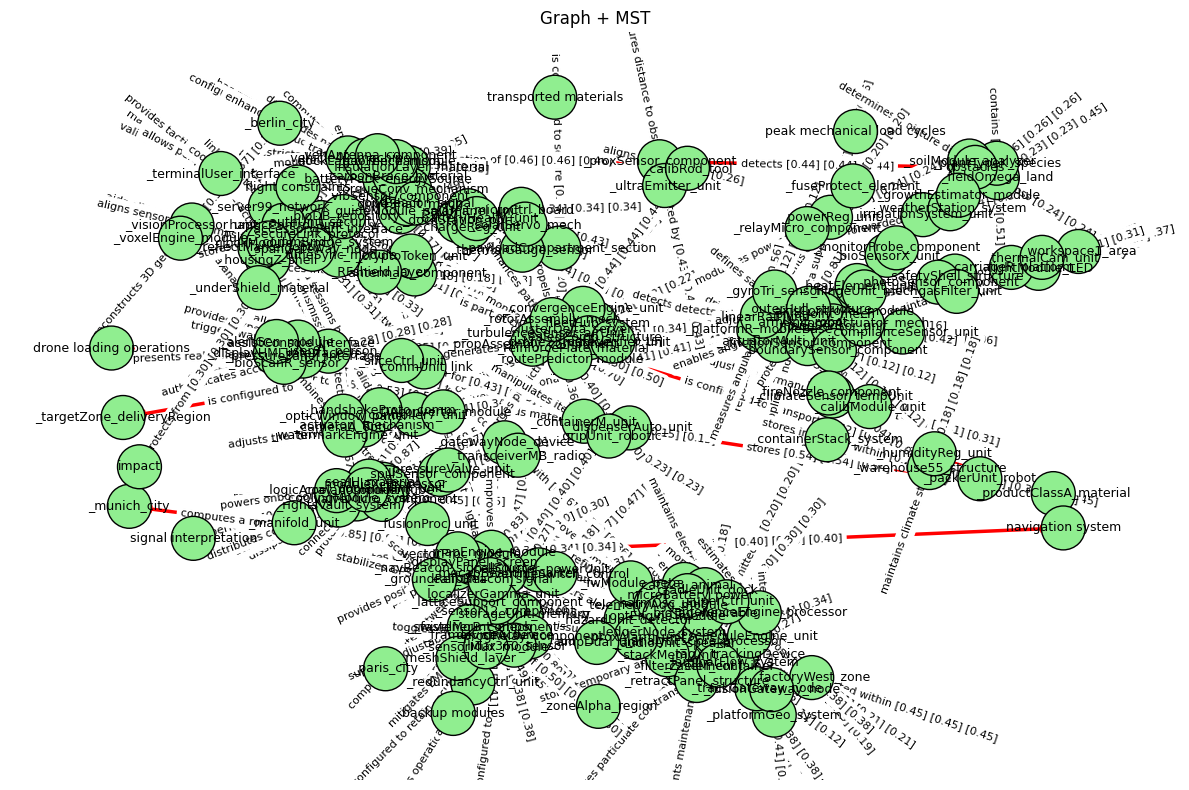

graph.html
✅ Interactive graph written to graph.html — open it in your browser.


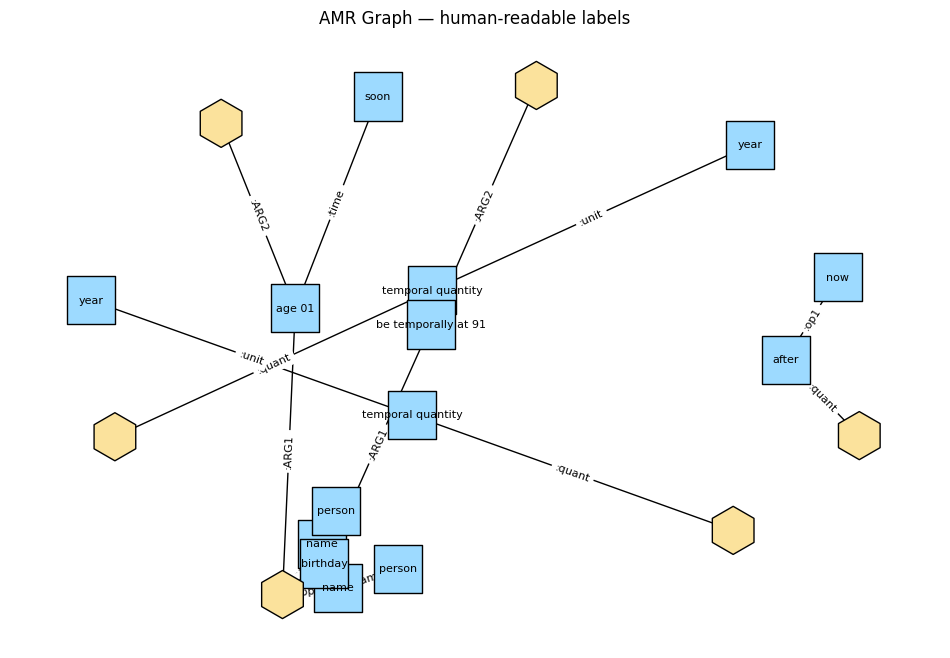

amr_graph.html
✅ Updated labels. Open amr_graph.html to explore interactively.


In [57]:

print("pyvis:", pyvis.__version__, "->", pyvis.__file__)
print("jinja2:", jinja2.__version__)
# Check if the template exists on disk:
tmpl_dir = os.path.join(os.path.dirname(pyvis.__file__), "templates")
print("template dir exists:", os.path.isdir(tmpl_dir))
if os.path.isdir(tmpl_dir):
    print("has template.html:", os.path.isfile(os.path.join(tmpl_dir, "template.html")))


pyvis: 0.3.2 -> c:\Users\Caleb\Documents\LLM Patent Claim Generator Thesis\.venv\Lib\site-packages\pyvis\__init__.py
jinja2: 3.1.6
template dir exists: True
has template.html: True


In [ ]:

client = epo_ops.Client(key=os.getenv("EPO_CONSUMER_KEY"), secret=os.getenv("EPO_CONSUMER_SECRET_KEY"))
print(os.getenv("EPO_CONSUMER_KEY"))


obP7iHGVo6HMzenhj3uXdl8T7E7zGPpVGhcRDthgmf6rzZmd


obP7iHGVo6HMzenhj3uXdl8T7E7zGPpVGhcRDthgmf6rzZmd
Description <?xml version="1.0" encoding="UTF-8"?><?xml-stylesheet type="text/xsl" href="../../../../style/pub-ftxt-description.xsl"?>
<ops:world-patent-data xmlns="http://www.epo.org/exchange" xmlns:ops="http://ops.epo.org" xmlns:xlink="http://www.w3.org/1999/xlink"><ftxt:fulltext-documents xmlns="http://www.epo.org/fulltext" xmlns:ftxt="http://www.epo.org/fulltext"><ftxt:fulltext-document system="ops.epo.org" fulltext-format="text-only"><bibliographic-data><publication-reference data-format="docdb"><document-id><country>EP</country><doc-number>1000000</doc-number><kind>A1</kind></document-id></publication-reference></bibliographic-data><description lang="EN"><p>[0001]    The invention relates to an apparatus for manufacturing green bricks from clay for the brick manufacturing industry, comprising a circulating conveyor carrying mould containers combined to mould container parts, a reservoir for clay arranged above the mould containers,

c:\Users\Caleb\Documents\LLM Patent Claim Generator Thesis\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Sentences: ['[0001]', 'The invention relates to an apparatus for manufacturing green bricks from clay for the brick manufacturing industry, comprising a circulating conveyor carrying mould containers combined to mould container parts, a reservoir for clay arranged above the mould containers, means for carrying clay out of the reservoir into the mould containers, means for pressing and trimming clay in the mould containers, means for supplying and placing take-off plates for the green bricks and means for discharging green bricks released from the mould containers.', 'Such an apparatus is known in the field and is for instance described in the patent 1000186 of applicant.', 'The known apparatus is extremely suitable for automated production of large numbers of green bricks for the brick manufacturing industry.', 'The bricks fired from these green bricks have a substantially smooth, uniform appearance.', '[0002]    A recent demand has developed on the market for bricks which appear as if

c:\Users\Caleb\Documents\LLM Patent Claim Generator Thesis\.venv\Scripts\python.exe


In [110]:
import torch
import networkx as nx

encoder = TextEncoder()

def get_root(node_id: str):
    parts = node_id.strip("_").split("_")
    return parts[0] if parts else node_id


for head, tail, key, data in G.edges(keys=True, data=True):

    # full readable labels
    head_txt = G.nodes[head].get("label", head)
    tail_txt = G.nodes[tail].get("label", tail)

    # relation text
    rel_text = data.get("relation", data.get("label", ""))

    # Weight node identity stronger than relation
    # This is critical for cosine threshold clustering
    text = (
        f"{head_txt} {head_txt} "       # head weight ×2
        f"{rel_text} "
        f"{tail_txt} {tail_txt}"        # tail weight ×2
    )

    embedding = encoder.embed_text_mean(text)

    data["embedding"] = embedding


Encoder using device: cuda


In [130]:
import torch
import torch.nn.functional as F    # ← REQUIRED for F.normalize


# ------------------------------
# Step 2: Build list of unassigned edges
# ------------------------------
unassigned = set(range(len(edge_list)))

# ------------------------------
# Step 3: Cosine-threshold region-growing
# ------------------------------
cluster_id = 0
SIM_THRESHOLD = 0.60     # adjust freely; clustering will change properly

while unassigned:

    # 1) Pick one seed edge to start a new cluster
    seed = unassigned.pop()
    seed_emb = F.normalize(embedding_list[seed], dim=0)

    cluster_edges = [seed]
    to_visit = [seed]

    # 2) BFS expansion based on cosine similarity
    while to_visit:
        cur = to_visit.pop()
        cur_emb = F.normalize(embedding_list[cur], dim=0)

        # Convert to list to avoid modifying 'unassigned' during iteration
        remaining = list(unassigned)

        for i in remaining:
            emb_i = F.normalize(embedding_list[i], dim=0)
            sim = torch.dot(cur_emb, emb_i).item()

            # If similar enough → merge into same cluster
            if sim >= SIM_THRESHOLD:
                unassigned.remove(i)
                cluster_edges.append(i)
                to_visit.append(i)

    # 3) Assign cluster_id to all collected edges
    for idx in cluster_edges:
        labels[idx] = cluster_id

    cluster_id += 1


In [134]:
for (head, tail, key), label in zip(edge_list, labels):
    G[head][tail][key]["cluster"] = int(label)


In [135]:
print({k: len(v) for k,v in buckets.items()})


{'': 211}


In [136]:
from collections import defaultdict

def print_triples_by_cluster(G, cluster_attr="cluster"):
    # cluster_id -> list of triple strings
    clusters = defaultdict(list)

    for head, tail, key, data in G.edges(keys=True, data=True):
        c = data.get(cluster_attr, -1)  # -1 for "no cluster"

        # Get readable node labels (fallback to id)
        head_text = G.nodes[head].get("label", str(head))
        tail_text = G.nodes[tail].get("label", str(tail))

        # Relation text (try "label", then "relation")
        relation_text = data.get("label", data.get("relation", ""))

        triple_str = f"({head_text}, {relation_text}, {tail_text})"
        clusters[c].append(triple_str)

    # Print nicely
    for c in sorted(clusters.keys()):
        if c == -1:
            print("\nUNCLUSTERED EDGES:")
        else:
            print(f"\nCLUSTER {c}:")
        for t in clusters[c]:
            print("  " + t)


# call it after you assigned edge["cluster"]
print_triples_by_cluster(G)



CLUSTER 0:
  (_vehicle42_machine, utilizes [0.31] [0.31] [0.31] [0.31], _batteryPack_energySource)
  (_vehicle42_machine, has propulsion subsystem with fuel source [0.23] [0.23] [0.23] [0.23], _batteryPack_energySource)
  (_vehicle42_machine, configured to navigate toward [0.45] [0.45] [0.45] [0.45], _berlin_city)
  (_vehicle42_machine, secured within [0.13] [0.13] [0.13] [0.13], _dockStation_port)
  (_batteryPack_energySource, is battery module of [0.38] [0.38] [0.38] [0.38], _vehicle42_machine)
  (_user01_person, interacts with [0.45] [0.45] [0.45] [0.45], _terminalUser_interface)
  (_user01_person, modifies control settings of [0.18] [0.18] [0.18] [0.18], _deviceA_device)
  (_terminalUser_interface, modifies control settings of [0.00] [0.00] [0.00] [0.00], _deviceA_device)
  (_deviceA_device, configured to receive sensory data from [0.47] [0.47] [0.47] [0.47], _sensor12_component)
  (_storageUnit_memory, configured to retain operational parameters associated with [0.47] [0.47] [0.4

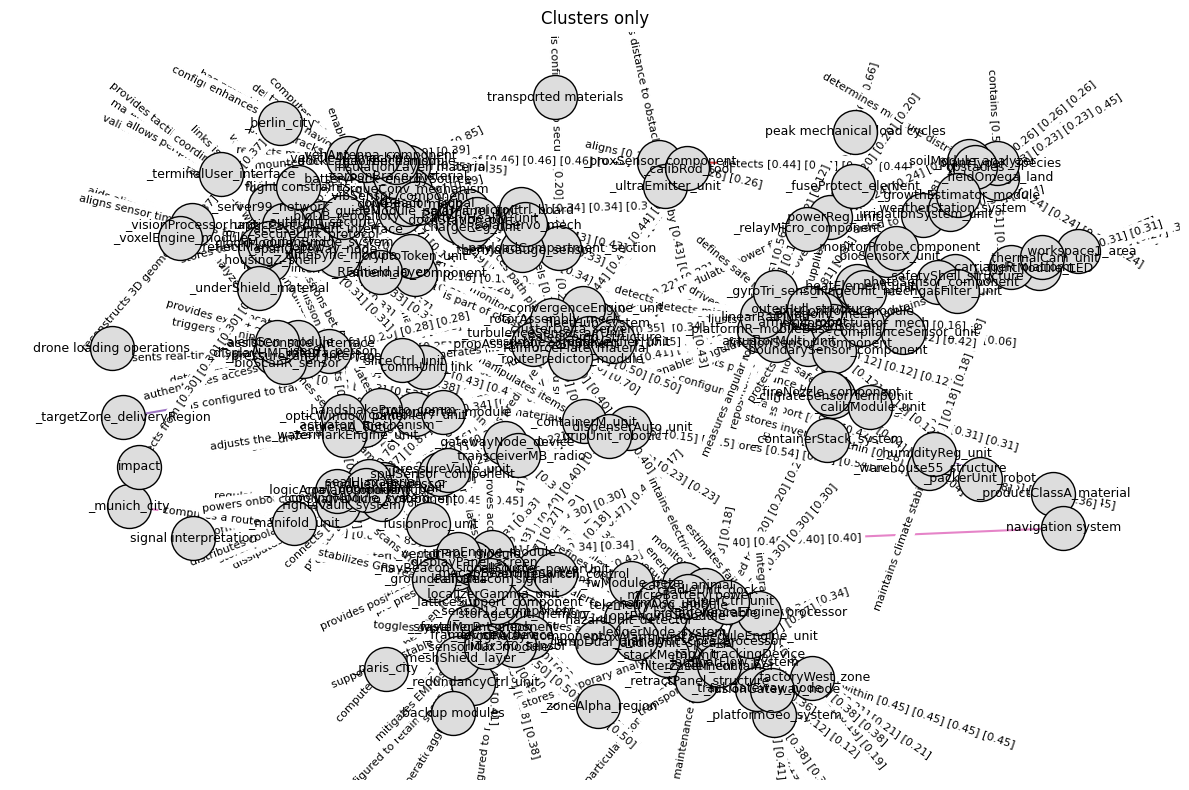

graph_clusters.html
✅ Interactive graph written to graph_clusters.html — open it in your browser.


In [102]:
visualize_matplotlib(G, title="Clusters only")
visualize_pyvis(G, out_file="graph_clusters.html")
